<a href="https://colab.research.google.com/github/Korchomnyi-Ivan/Korchomnyi-Ivan-Machine-3-15/blob/main/%D0%9B%D0%A0_8_%D0%9A%D0%BE%D1%80%D1%87%D0%BE%D0%BC%D0%BD%D0%BE%D0%B3%D0%BE_%D0%86_%D0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Був присутній на парі

In [203]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN, MiniBatchKMeans
from sklearn.decomposition import PCA

In [204]:
uploaded = files.upload()

Saving possum.csv to possum (4).csv


In [205]:
df = pd.read_csv('possum.csv')

df

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,100,7,other,m,1.0,89.5,56.0,81.5,36.5,66.0,46.8,14.8,23.0,27.0
100,101,7,other,m,1.0,88.6,54.7,82.5,39.0,64.4,48.0,14.0,25.0,33.0
101,102,7,other,f,6.0,92.4,55.0,89.0,38.0,63.5,45.4,13.0,25.0,30.0
102,103,7,other,m,4.0,91.5,55.2,82.5,36.5,62.9,45.9,15.4,25.0,29.0


In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   case      104 non-null    int64  
 1   site      104 non-null    int64  
 2   Pop       104 non-null    object 
 3   sex       104 non-null    object 
 4   age       102 non-null    float64
 5   hdlngth   104 non-null    float64
 6   skullw    104 non-null    float64
 7   totlngth  104 non-null    float64
 8   taill     104 non-null    float64
 9   footlgth  103 non-null    float64
 10  earconch  104 non-null    float64
 11  eye       104 non-null    float64
 12  chest     104 non-null    float64
 13  belly     104 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 11.5+ KB


case — унікальний ідентифікатор (номер) кожного спостереження.

site — номер локації, де було знайдено тварину (всього 7 сайтів).

Pop — приналежність до популяції (Vic — Вікторія, other — Новий Південний Уельс та Квінсленд).

sex — стать тварини (m — самець, f — самка).

age — вік посума в роках (має незначні пропуски в даних).

hdlngth — довжина голови (head length) у мм.

skullw — ширина черепа (skull width) у мм.

totlngth — загальна довжина тіла від носа до кінчика хвоста.

taill — довжина самого хвоста.

footlgth — довжина стопи.

earconch — довжина вушної раковини.

eye — відстань між зовнішніми кутами очей.

chest — обхват грудної клітки.

belly — обхват живота.

In [207]:
df['sex' ].value_counts()

,count
sex,
m,61
f,43


In [208]:
df['Pop'].value_counts()

,count
Pop,
other,58
Vic,46


In [209]:
df['sex' ] = df['sex'].map({'m': 1, 'f': 0})

In [210]:
df['Pop'] = df['Pop'].map({'Vic': 1, 'other': 0})

In [211]:
df.dtypes

,0
case,int64
site,int64
Pop,int64
sex,int64
age,float64
hdlngth,float64
skullw,float64
totlngth,float64
taill,float64
footlgth,float64


In [212]:
df.isnull().sum()

,0
case,0
site,0
Pop,0
sex,0
age,2
hdlngth,0
skullw,0
totlngth,0
taill,0
footlgth,1


In [213]:
df.dropna(inplace=True)

In [214]:
df.isnull().sum()

,0
case,0
site,0
Pop,0
sex,0
age,0
hdlngth,0
skullw,0
totlngth,0
taill,0
footlgth,0


In [215]:
df.describe()

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,52.762376,3.673267,0.425743,0.584158,3.821782,92.730693,56.960396,87.269307,37.049505,68.398020,48.133663,15.050495,27.064356,32.638614
std,30.573894,2.366892,0.496921,0.495325,1.915182,3.518714,3.102679,4.196802,1.971681,4.413502,4.060352,1.058643,2.020722,2.727745
min,1.000000,1.000000,0.000000,0.000000,1.000000,82.500000,50.000000,75.000000,32.000000,60.300000,41.300000,12.800000,22.000000,25.000000
25%,26.000000,1.000000,0.000000,0.000000,2.000000,90.700000,55.000000,84.500000,36.000000,64.500000,44.800000,14.400000,25.500000,31.000000
50%,54.000000,4.000000,0.000000,1.000000,3.000000,92.900000,56.400000,88.000000,37.000000,67.900000,46.800000,14.900000,27.000000,32.500000
75%,79.000000,6.000000,1.000000,1.000000,5.000000,94.800000,58.100000,90.000000,38.000000,72.500000,52.000000,15.700000,28.000000,34.000000
max,104.000000,7.000000,1.000000,1.000000,9.000000,103.100000,68.600000,96.500000,43.000000,77.900000,56.200000,17.800000,32.000000,40.000000


In [216]:
df['site' ].value_counts()

,count
site,
1,33
7,18
5,13
6,13
2,10
3,7
4,7


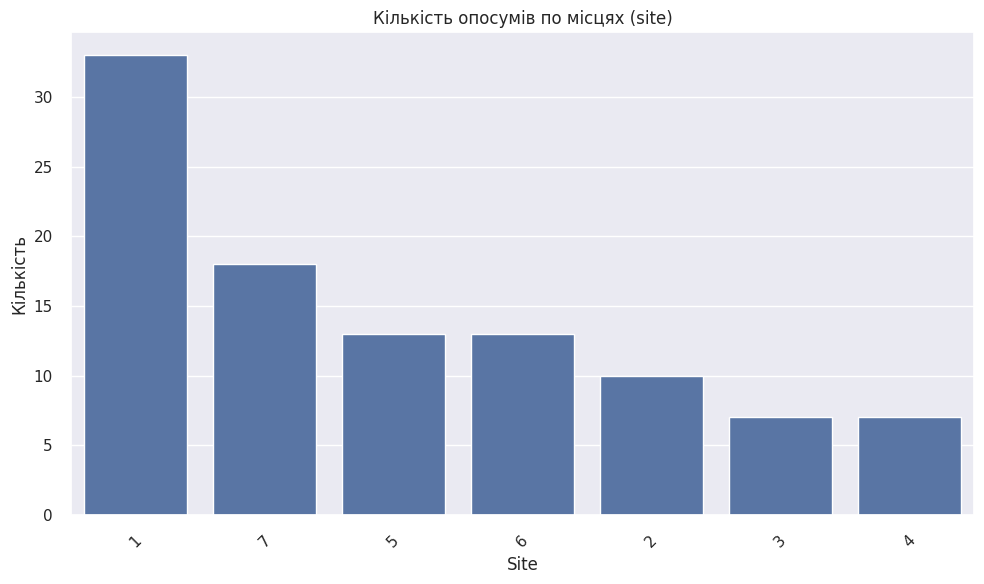

In [217]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='site', order=df['site'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Кількість опосумів по місцях (site)')
plt.xlabel('Site')
plt.ylabel('Кількість')
plt.tight_layout()
plt.show()

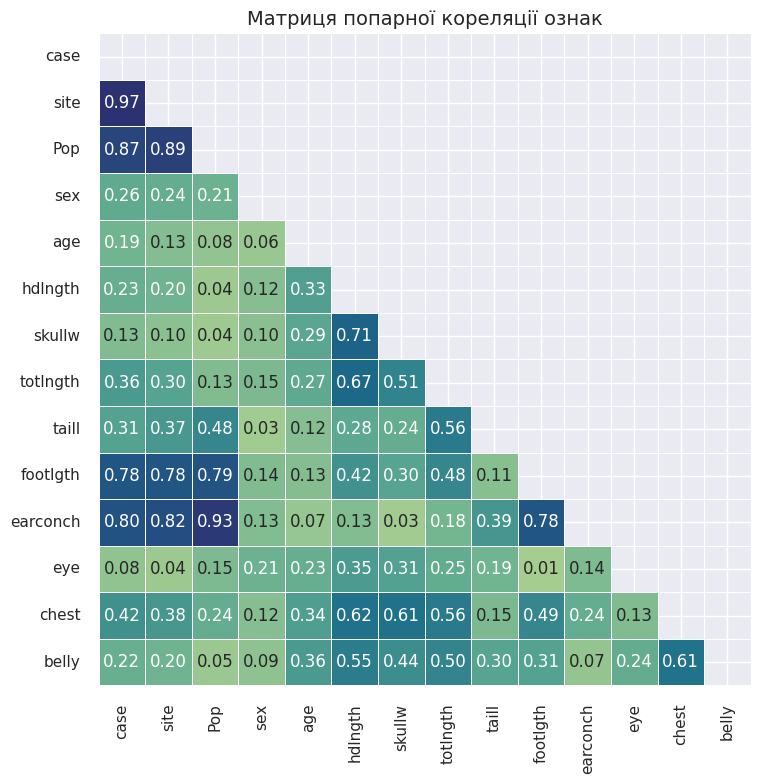

In [218]:
mtx = df.corr(numeric_only=True).abs()

fig, ax = plt.subplots(figsize=(8, 8))

sns.heatmap(
    mtx,
    cmap='crest',
    annot=True,
    fmt=".2f",
    linewidths=.5,
    mask=np.triu(np.ones_like(mtx, dtype=bool)),
    square=True,
    cbar=False,
    ax=ax
)

plt.title("Матриця попарної кореляції ознак", fontsize=14)
plt.tight_layout()
plt.show()

In [219]:
df.corrwith(df['Pop']).abs().sort_values(ascending=False)

,0
Pop,1.000000
earconch,0.925583
site,0.892316
case,0.868030
footlgth,0.791939
taill,0.481018
chest,0.241328
sex,0.207966
eye,0.147726
totlngth,0.133877


In [220]:
features = df[['hdlngth', 'skullw', 'totlngth', 'taill', 'footlgth', 'earconch', 'eye', 'chest', 'belly' ]]
features

,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0
...,...,...,...,...,...,...,...,...,...
99,89.5,56.0,81.5,36.5,66.0,46.8,14.8,23.0,27.0
100,88.6,54.7,82.5,39.0,64.4,48.0,14.0,25.0,33.0
101,92.4,55.0,89.0,38.0,63.5,45.4,13.0,25.0,30.0
102,91.5,55.2,82.5,36.5,62.9,45.9,15.4,25.0,29.0


In [221]:
scaler = StandardScaler()
X_scaled = scaler. fit_transform(features)

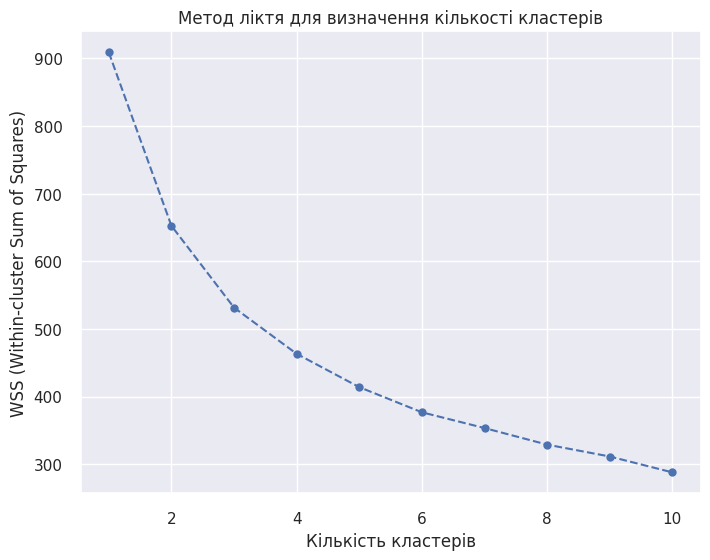

In [222]:
wss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wss, marker='o', linestyle='--')
plt.title('Метод ліктя для визначення кількості кластерів')
plt.xlabel('Кількість кластерів')
plt.ylabel('WSS (Within-cluster Sum of Squares)')
plt.grid(True)
plt.show()

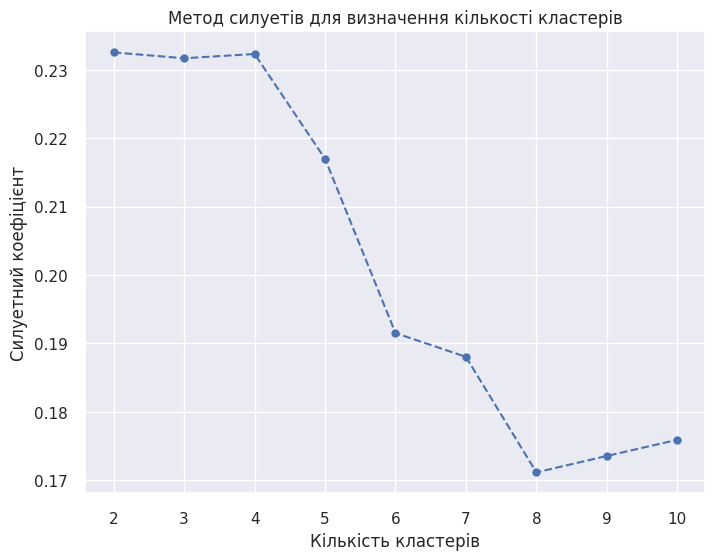

In [223]:
silhouette_scores = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42,n_init=10)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Метод силуетів для визначення кількості кластерів')
plt.xlabel('Кількість кластерів')
plt.ylabel('Силуетний коефіцієнт')
plt.grid(True)
plt.show()

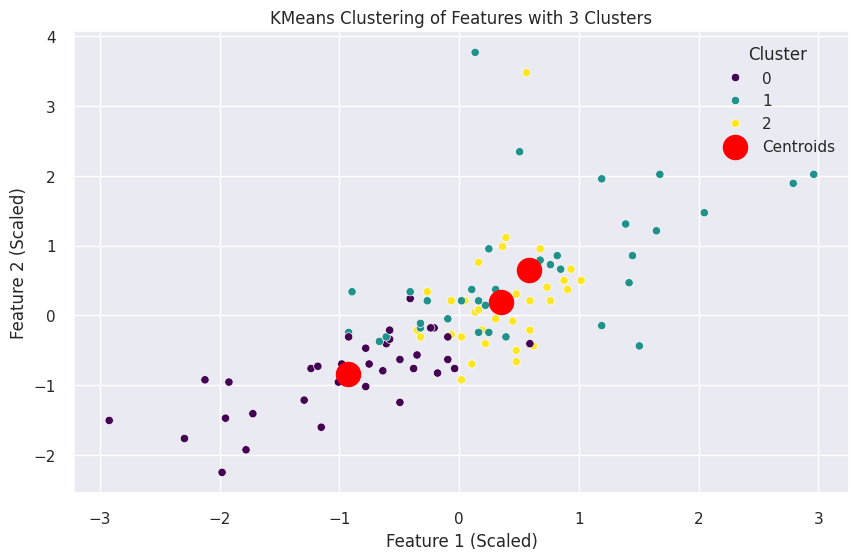

In [224]:
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans. fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[ :, 1], hue=clusters, palette='viridis', legend='full')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans. cluster_centers_[:, 1], s=300, c='red', label='Centroids' )

plt.title('KMeans Clustering of Features with 3 Clusters')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.legend(title='Cluster' )
plt.grid(True)
plt.show()

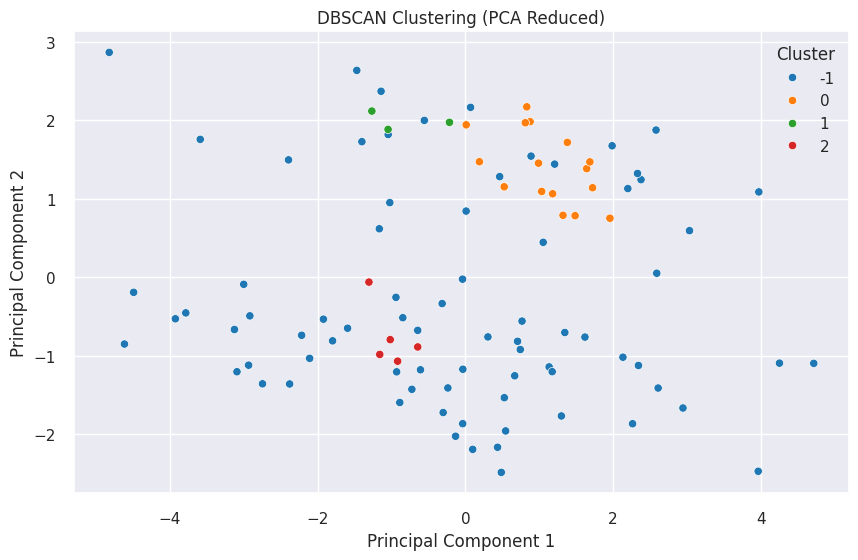

In [225]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
clusters_db = dbscan.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[ :, 1], hue=clusters_db, palette='tab10', legend='full' )

plt.title('DBSCAN Clustering (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

2 спосіб

In [226]:
!pip install kneed --quiet

In [227]:
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns
from kneed import KneeLocator

from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

In [228]:
X = df

X = StandardScaler().fit_transform(x)

pca = PCA(random_state=42).fit(x)
pve = pca. explained_variance_ratio_

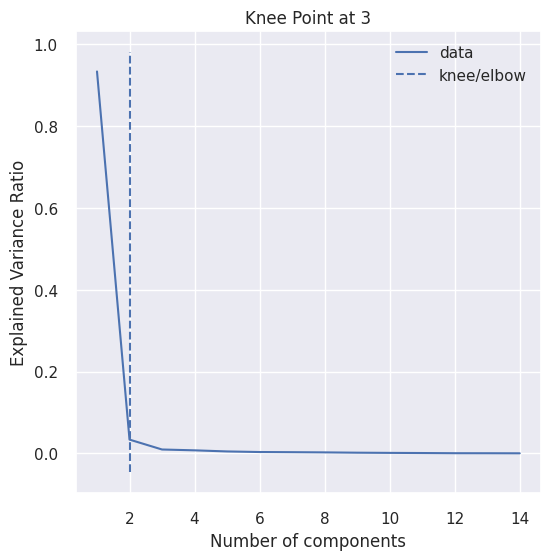

In [229]:
sns.set_theme()

kneedle = KneeLocator(
x=range(1, len(pve) + 1),
y=pve,
curve='convex',
direction='decreasing'
)

kneedle.plot_knee()
plt.title(f'Knee Point at {kneedle.elbow + 1}')
plt.xlabel("Number of components")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.show()

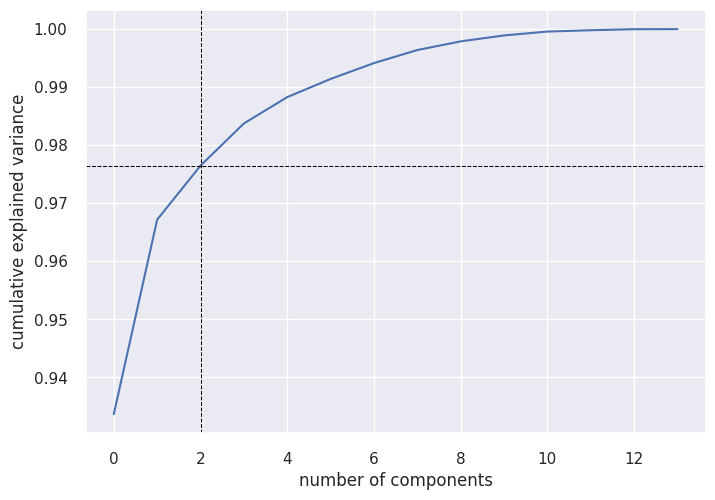

In [230]:
n_components = kneedle.elbow

ax = sns.lineplot (np.cumsum(pve))

ax.axvline(x=n_components,
c='black',
linestyle='--',
linewidth=0.75)

ax.axhline(y=np.cumsum(pve)[n_components],
c='black',
linestyle='--',
linewidth=0.75)

ax.set(xlabel='number of components',
ylabel='cumulative explained variance' )

plt.show()

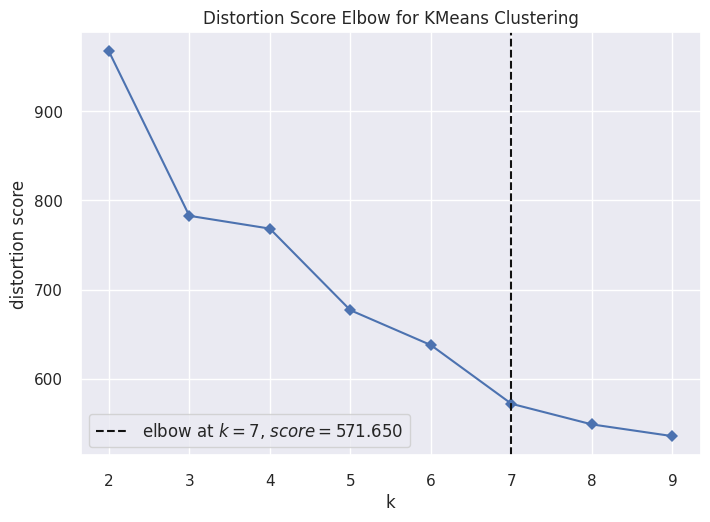

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [231]:
model_kmn = KMeans (random_state=42)

visualizer = KElbowVisualizer(
model_kmn,
k=(2, 10),
timings=False)

visualizer.fit(X)
visualizer.show()

In [232]:
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)

In [233]:
model_agg = AgglomerativeClustering(
  distance_threshold=0,
  n_clusters=None)

model_agg = model_agg.fit(X)

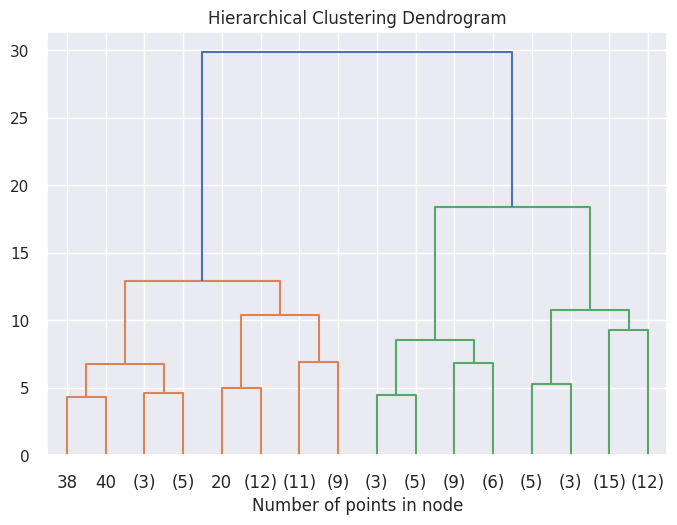

In [234]:
plot_dendrogram(model_agg, truncate_mode='level', p=3)
plt.title('Hierarchical Clustering Dendrogram' )
plt.xlabel('Number of points in node')

plt.show()

In [235]:
k_best = visualizer.elbow_value_

model_kmn = KMeans(n_clusters=k_best, random_state=42).fit(X)
model_agg = AgglomerativeClustering(n_clusters=k_best).fit(X)

labels_kmn = pd.Series(model_kmn. labels_, name='k-means' )
labels_agg = pd.Series(model_agg.labels_, name='h-clust' )

In [236]:
pd.crosstab(df['Pop'], labels_kmn)

k-means,0,1,2,3,4,5,6
Pop,,,,,,,
0,0,19,0,28,0,0,8
1,1,0,17,0,17,7,1


In [237]:
pd.crosstab(df['Pop'], labels_agg)

h-clust,0,1,2,3,4,5,6
Pop,,,,,,,
0,22,0,12,0,8,0,13
1,0,20,0,9,0,13,1


Висновок: При виконання даної лабораторної роботи Було виконано кластеризацію даних методами K-Means та ієрархічної кластеризації, а оптимальну кількість кластерів визначено за методом ліктя і силуету. У результаті дані успішно поділено на групи, що підтверджує наявність структури в них.